In [1]:
from tdc.multi_pred import DrugRes
data = DrugRes(name = 'GDSC1', path='../data/Cancer/tdc2')
split = data.get_split()


Downloading...
100%|███████████████████████████████████████| 140M/140M [01:15<00:00, 1.87MiB/s]
Loading...
Done!


In [5]:
data.get_gene_symbols()

Downloading...
100%|███████████████████████████████████████| 149k/149k [00:00<00:00, 1.00MiB/s]
Loading...


array(['TSPAN6', 'TNMD', 'DPM1', ..., 'UBL5P2', 'TBC1D3P5', nan],
      dtype=object)

In [7]:
gdsc1 = data.get_data(format = 'df')

In [13]:
gdsc1.head()

,Drug_ID,Drug,Cell Line_ID,Cell Line,Y
0,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,MC-CAR,"[3.23827250519154, 2.98225419469807, 10.235490...",2.395685
1,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,ES3,"[8.690197905033282, 3.0914731119366, 9.9924871...",3.140923
2,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,ES5,"[8.233101127037282, 2.82468731112752, 10.01588...",3.968757
3,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,ES7,"[8.33346622426757, 3.9667571228514302, 9.79399...",2.692768
4,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,EW-11,"[8.39134072442845, 2.9683601858810698, 10.2606...",2.478678


In [24]:
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt


drug_list = gdsc1["Drug_ID"].unique().tolist()
cell_list = gdsc1["Cell Line_ID"].unique().tolist()


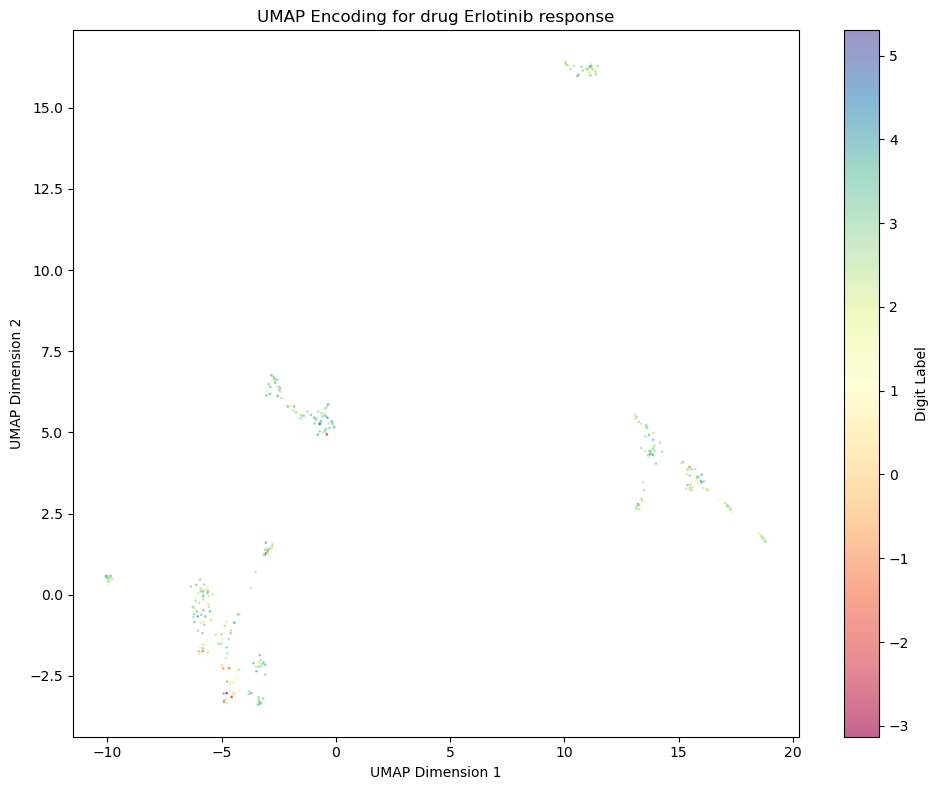

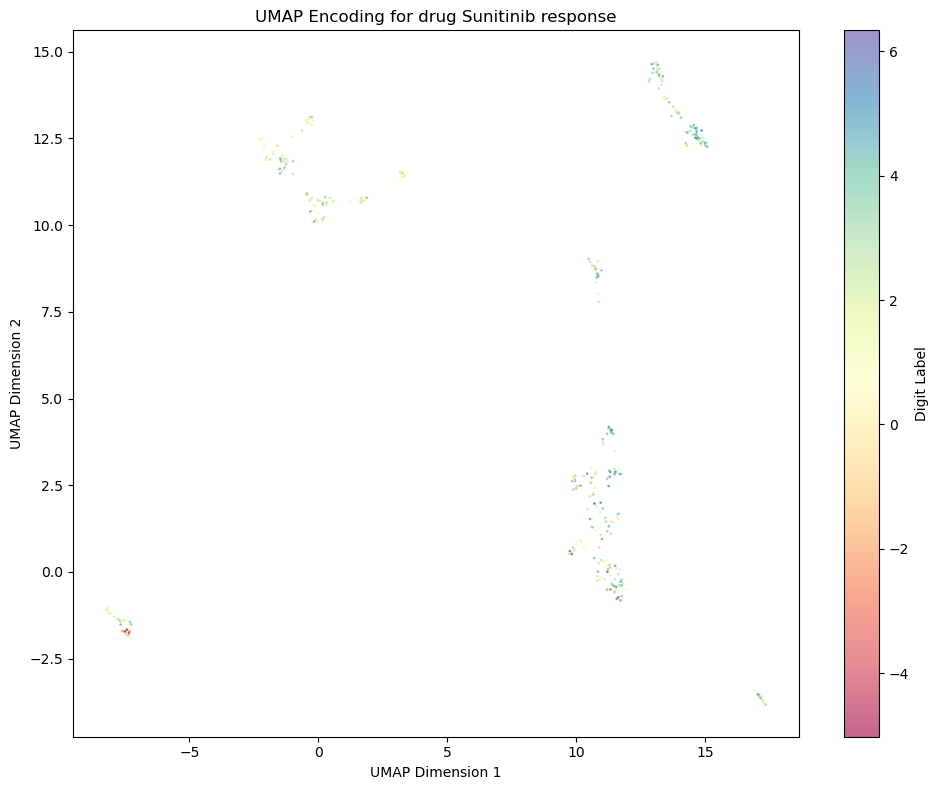

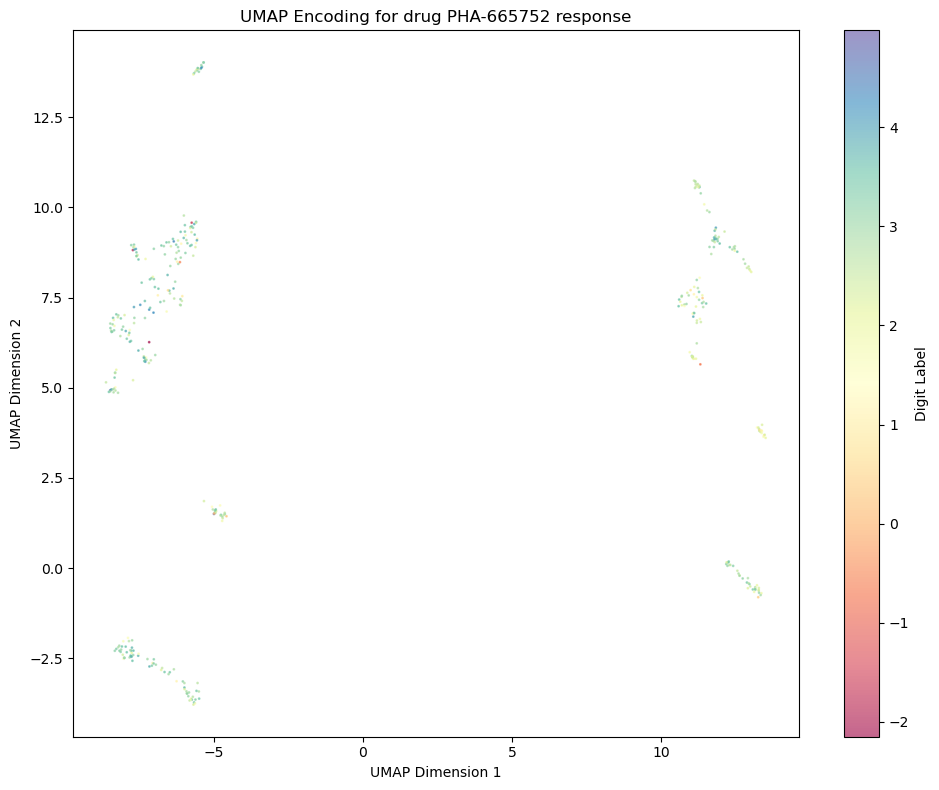

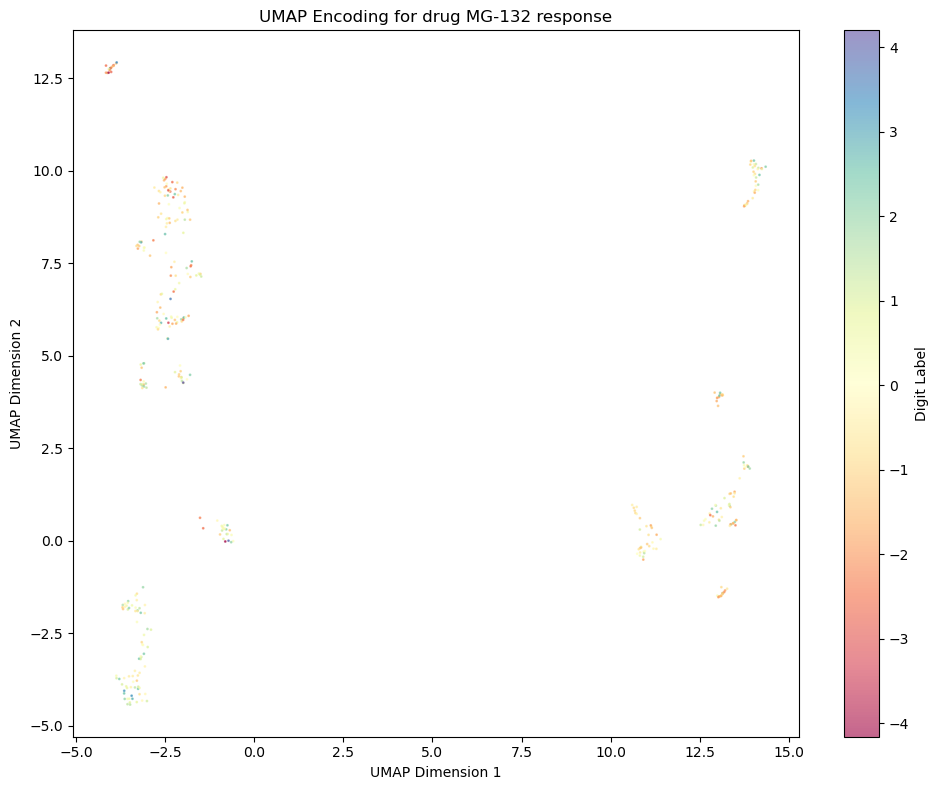

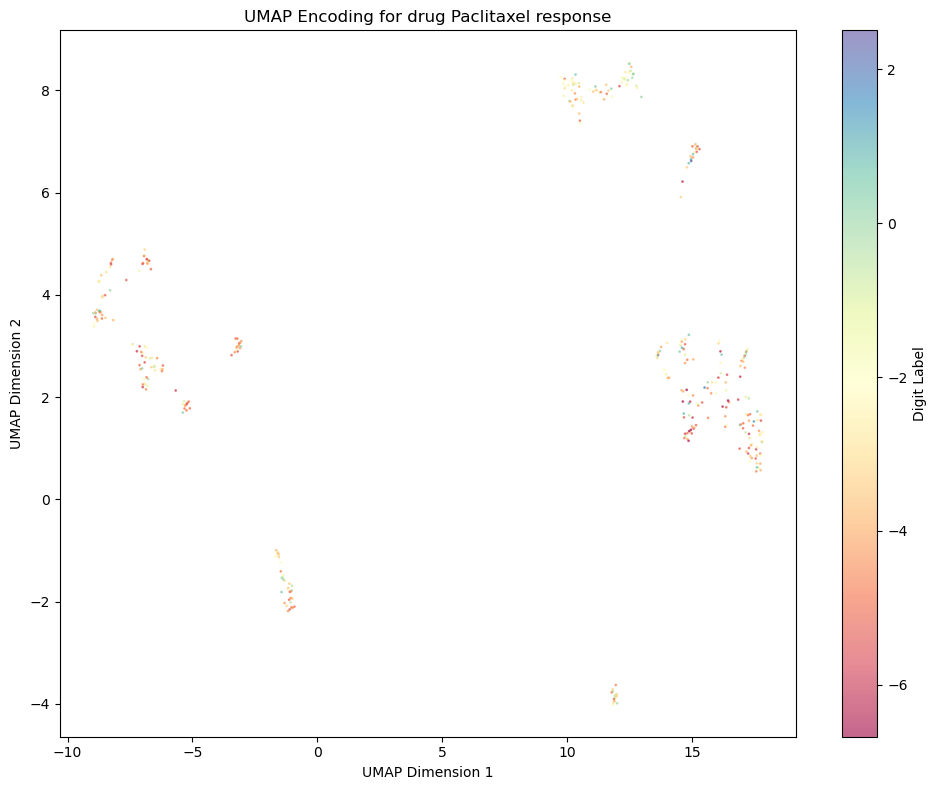

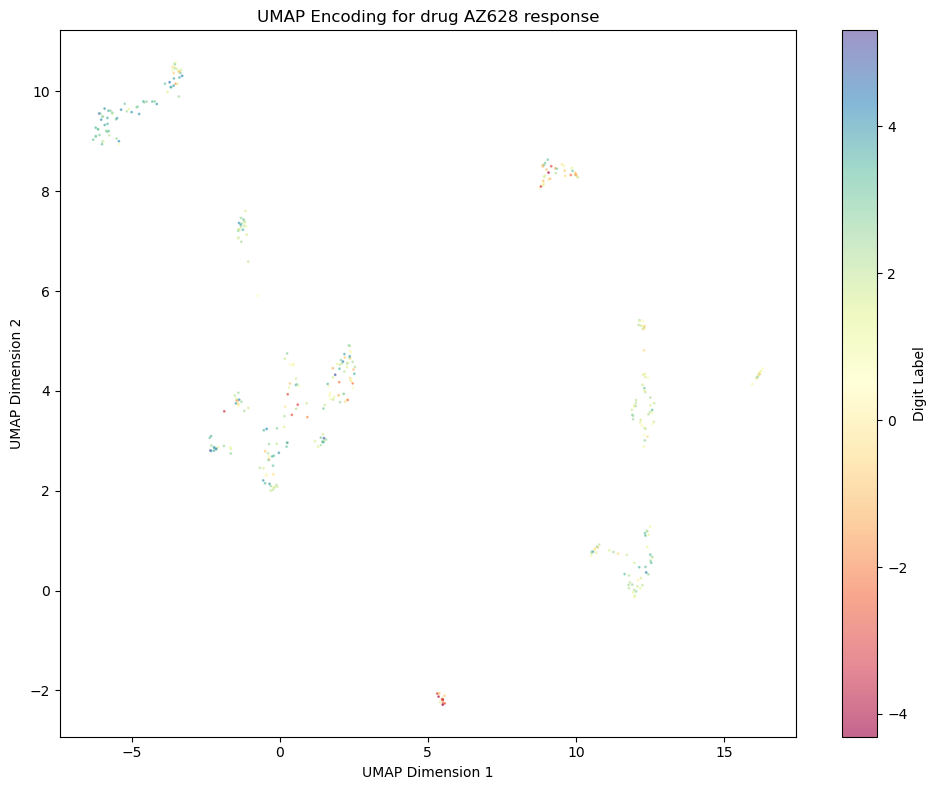

In [25]:
drug_response = {}
top = 4
for idx, drug in enumerate(drug_list):
    X = []
    y = []
    for cell in cell_list:
        entry = gdsc1[(gdsc1["Drug_ID"]==drug) & (gdsc1["Cell Line_ID"]==cell)]
        if not entry.empty:
            X.append(entry.iloc[0]["Cell Line"])
            y.append(entry.iloc[0]["Y"])
    training_x = np.array(X)
    training_y = np.array(y)
    drug_response[drug] = {"cell_line": training_x, "log_ic50": training_y}
    umap = UMAP()
    # Fit and transform the data
    X_train_umap = umap.fit_transform(training_x)
    
    # Plot the results
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=training_y, cmap="Spectral", s=1, alpha=0.6)
    plt.colorbar(scatter, label="Digit Label")
    plt.title("UMAP Encoding for drug {} response".format(drug))
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    # Show the plot
    plt.tight_layout()
    plt.show()
    if (idx > top):
        break

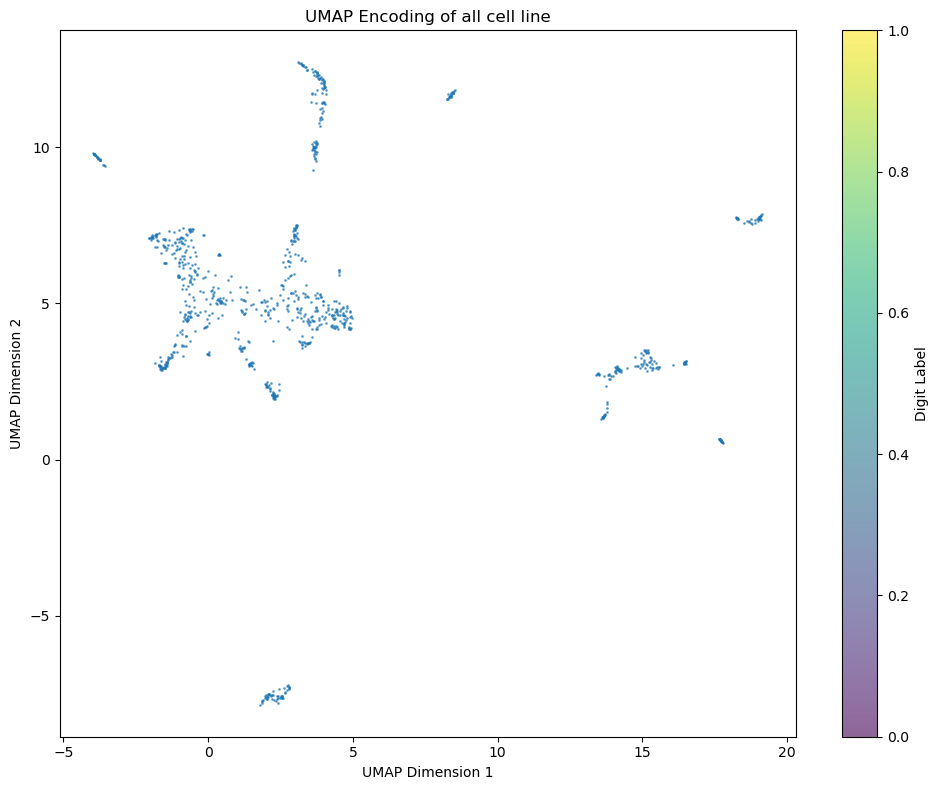

In [42]:
gdsc1_cells = gdsc1.drop_duplicates(subset=['Cell Line_ID'], keep='first')
training_x = gdsc1_cells["Cell Line"].values
training_x = np.stack(training_x)

umap = UMAP()
# Fit and transform the data
X_train_umap = umap.fit_transform(training_x)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding of all cell line")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()